# AutoML Lab · tabular engine — Regression demo

A fully automated modeling workflow: **drop in a dataset, name the
target, Run All, get a deployable model back** — with the guardrails,
leaderboard discipline, and documentation you'd expect from a commercial
AutoML platform, implemented on scikit-learn.

This notebook is a thin, narrated driver. All logic lives in the importable,
unit-tested [`automl` package](../automl/) one directory up, so the same engine
powers the classification and regression templates without copy-paste drift.


| Stage | What happens |
|---|---|
| `load` | profiling, quality guardrails, date/text feature prep, decision log |
| `split` | locked holdout + CV strategy (random / time-aware / group-aware), metric auto-selection |
| `scan_leakage` | two-detector target-leakage scan |
| `prune_correlation` | pairwise correlation pruning |
| `screen` | every model family cross-validated under identical folds |
| `tune` | Optuna on the finalists, defaults kept as the baseline |
| `rescore` | stacking/voting blenders join; fresh-fold re-score picks the champion |
| `evaluate` | calibration repair, operating point, holdout metrics + bootstrap CIs |
| `explain` | permutation importance, partial dependence, SHAP |
| `export` | model.joblib, metadata.json, predict.py, drift_check.py, Dockerfile, report.html |


**Demo dataset:** [Diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) (53,940 rows): predict price from carat, cut, color, clarity and dimensions. A right-skewed, strictly positive target — exactly the shape that trips up naive squared-error modeling — plus ordered categoricals and enough rows to trigger stage-1 sampling.

**Runtime:** ~20–35 minutes on 4 cores with the settings below. Use `AutoMLConfig.fast(...)` for a first pass in
a couple of minutes.

Every automated decision is printed as it happens and lands in a decision log
that ships with the artifact — automation should never be a black box.

## 0 · Configuration

In [1]:
import sys
sys.path.insert(0, "..")                    # notebooks/ -> repo folder with automl/

from automl import AutoML, AutoMLConfig

CONFIG = AutoMLConfig(
    # ----- point these at your data, then Run All ---------------------------
    data_path=None,                         # .csv / .parquet; None -> demo dataset below
    target="price",
    task="regression",                      # or "auto" to infer from the target

    # ----- budget (the two knobs that trade accuracy for wall-clock) --------
    optuna_trials=12,                       # per finalist
    optuna_timeout=240,                     # seconds per finalist, whichever first

    artifact_dir="artifacts_regression",
)

aml = AutoML(CONFIG)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data

In [2]:
import pandas as pd

if CONFIG.data_path is None:
    DIAMONDS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
    df = pd.read_csv(DIAMONDS_URL)
else:
    df = None                               # the engine reads CONFIG.data_path itself

df.head() if df is not None else None

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2 · Profile & quality guardrails

Feature profiling with logged drops (missingness, constants, ID-like columns), datetime decomposition, text vectorization, duplicate-row removal — see the classification template for the full rationale; the engine is shared.

In [3]:
aml.load(df)

[ingest] Dropped 146 duplicate rows — duplicates straddling the train/holdout boundary would inflate every score
[quality] Normalized 3 categorical column(s) to string dtype
[quality] 0 feature(s) dropped, 9 remain (0 text)
Rows: 53,794   Features: 9   Task: regression


,dtype,missing_%,n_unique,flags
feature,,,,
carat,float64,0.0,273,—
cut,str,0.0,5,—
color,str,0.0,7,—
clarity,str,0.0,8,—
depth,float64,0.0,184,—
table,float64,0.0,127,—
x,float64,0.0,554,—
y,float64,0.0,552,—
z,float64,0.0,375,—


## 3 · Partition, metric & objective family

The holdout split is stratified on **target deciles** so skewed tails are represented on both sides. Metric selection is distribution-aware and uses training rows only:

- roughly symmetric target → **RMSE**;
- heavy skew or extreme outliers → **MAE**, *and the gradient-boosting rosters switch to absolute-error objectives* so models optimize the metric they're ranked on;
- non-negative integers → Poisson-objective variants; zero-inflated → Tweedie; strictly positive & skewed → Gamma and **log1p-target siblings** (`TransformedTargetRegressor`, scored on the original scale) join the leaderboard so the data decides raw vs log.

In [4]:
aml.split()

[partition] Regression holdout stratified on target deciles (protects the tails on skewed targets)
[partition] Train 43,035 rows / holdout 10,759 rows (locked until final evaluation); 5-fold CV
[metric] Target reasonably symmetric (skew=1.62) -> primary metric RMSE
[objective] Strictly positive skewed target -> log1p-target model variants join the leaderboard (TransformedTargetRegressor; scored on the original scale, so directly comparable)


## 4 · Target-leakage scan

|Spearman| vs the target **and** a depth-6 single-feature tree — the correlation detector exists because a shallow tree's R² ceiling lets even a literal copy of a continuous target through (a real failure mode of the notebook this engine replaced).

In [5]:
aml.scan_leakage().head(15)

[leakage] No leakage flags raised


,single_feature_score,abs_spearman_vs_target,leakage_flag
feature,,,
y,0.873141,0.963317,False
carat,0.869833,0.963404,False
x,0.869311,0.964110,False
z,0.858160,0.959155,False
clarity,0.025811,NaN,False
color,0.024867,NaN,False
table,0.023465,0.185066,False
cut,0.014808,NaN,False
depth,-0.009009,0.005975,False


## 5 · Correlation pruning

Diamonds' physical dimensions (x/y/z vs carat) are near-duplicates — watch the pruner keep the strongest twin.

In [6]:
aml.prune_correlation()

[correlation] Dropping 'x' (|ρ|=0.998 with 'y', weaker target association)
[correlation] Dropping 'carat' (|ρ|=0.996 with 'y', weaker target association)
[correlation] Dropping 'z' (|ρ|=0.987 with 'y', weaker target association)
[features] Final feature set: 6 features (3 numeric, 3 categorical, 0 high-cardinality categorical, 0 text)


['x', 'carat', 'z']

## 6 · Leaderboard, stage 1 — screening

All families under identical folds, on a capped sample for large data (cheap elimination now, honest full-data re-scoring before any ranking that matters).

In [7]:
aml.screen()

[roster] Roster (10 models): ['Ridge', 'ElasticNet', 'RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting_logy', 'LightGBM_logy']
[leaderboard] Stage-1 screening on a 20,000-row sample of 43,035 train rows (finalists are re-scored on the full partition later, so mixed-basis scores never decide the champion)


  Ridge                        RMSE=1571.8190  (0.2s)


  ElasticNet                   RMSE=2162.2078  (0.2s)


  RandomForest                 RMSE=602.0715  (23.3s)


  ExtraTrees                   RMSE=608.3974  (20.8s)


...

  LightGBM                     RMSE=583.4380  (0.9s)


  CatBoost                     RMSE=575.0431  (1.9s)


  HistGradientBoosting_logy    RMSE=573.0322  (1.0s)


  LightGBM_logy                RMSE=571.9830  (0.9s)


,model,RMSE,RMSE_std,fit_time_s,mae,r2
1,LightGBM_logy,571.982975,14.810470,0.4,300.142283,0.979136
2,HistGradientBoosting_logy,573.032197,16.243181,0.4,301.768937,0.979057
3,CatBoost,575.043096,13.452039,0.9,308.645491,0.978920
4,HistGradientBoosting,577.531500,16.758388,0.4,308.942761,0.978726
5,LightGBM,583.437962,13.023485,0.3,308.834792,0.978294
6,XGBoost,594.214814,11.662330,0.4,309.071241,0.977492
7,RandomForest,602.071538,18.583547,11.8,321.845886,0.976892
8,ExtraTrees,608.397431,20.392007,9.9,324.639738,0.976414
9,Ridge,1571.819047,35.826947,0.1,1190.558975,0.842574
10,ElasticNet,2162.207756,40.314584,0.1,1413.641744,0.702208


## 7 · Stage 2 — tuning with a default-config guarantee

Optuna per finalist; defaults always compete; early stopping owns the tree count for gradient boosting.

In [8]:
tuned = aml.tune()

Finalists advancing to tuning: ['LightGBM_logy', 'HistGradientBoosting_logy', 'CatBoost']


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[tuning] LightGBM_logy: defaults kept — no trial beat them (best trial 579.4815 vs default 578.9229, 6/6 trials, 266s)


[tuning] HistGradientBoosting_logy: tuned beats defaults (580.2205 vs 583.5300, 12/12 trials, 56s)


[tuning] CatBoost: tuned beats defaults (586.8394 vs 591.0758, 3/3 trials, 520s)


## 8 · Blenders & the de-biased final leaderboard

Stacking + voting blenders join, then every candidate gets one honest CV pass on fresh folds. The champion comes from this column only.

In [9]:
aml.rescore()

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[tuning] LightGBM_logy: early stopping froze the tree count at 273 (validation-chosen 249, +10% headroom for the full-data fit)


[tuning] CatBoost: early stopping froze the tree count at 2200 (validation-chosen 2000, +10% headroom for the full-data fit)
[ensemble] Blender candidates join the final re-score: ['Stacked(3)', 'Voting(3)']


  LightGBM_logy                final RMSE=578.7345  (3.0s)


  HistGradientBoosting_logy    final RMSE=580.9830  (3.0s)


  CatBoost                     final RMSE=584.2461  (58.5s)


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Stacked(3)                   final RMSE=570.6737  (373.1s)


  Voting(3)                    final RMSE=571.3164  (64.8s)
[leaderboard] Deployment pick: Voting(3) (571.3164) — within one standard error of the paired fold differences (0.7299) of Stacked(3) (570.6737), and a simpler model is cheaper to deploy, retrain, and explain. The leaderboard stays accuracy-ranked; set champion_policy='parsimonious' to ship the pick instead
[leaderboard] Champion: Stacked(3) (fresh-fold CV RMSE=570.6737)


,model,screen_RMSE,final_RMSE,final_std,source
1,Stacked(3),NaN,570.673657,22.1332,blender · fresh-fold CV
2,Voting(3),NaN,571.316363,21.4910,blender · fresh-fold CV
3,HistGradientBoosting,577.531500,NaN,NaN,stage-1 screen
4,LightGBM_logy,571.982975,578.734514,21.3477,defaults · fresh-fold CV
5,HistGradientBoosting_logy,573.032197,580.982973,21.4503,tuned · fresh-fold CV
6,LightGBM,583.437962,NaN,NaN,stage-1 screen
7,CatBoost,575.043096,584.246071,22.1490,tuned · fresh-fold CV
8,XGBoost,594.214814,NaN,NaN,stage-1 screen
9,RandomForest,602.071538,NaN,NaN,stage-1 screen
10,ExtraTrees,608.397431,NaN,NaN,stage-1 screen


## 9 · Final evaluation on the locked holdout

Predicted-vs-actual, residuals, a lift chart (rank quality and calibration at a glance), and bootstrap confidence intervals for RMSE/MAE/R².

Champion: Stacked(3)
  holdout RMSE      : 538.3501
  holdout MAE       : 279.2727
  holdout median_AE : 120.5278
  holdout R2        : 0.9819


,point,ci_2.5%,ci_97.5%,n_resamples
RMSE,538.3501,514.7816,560.4093,1000.0
MAE,279.2727,270.6234,288.3474,1000.0
R2,0.9819,0.9804,0.9833,1000.0


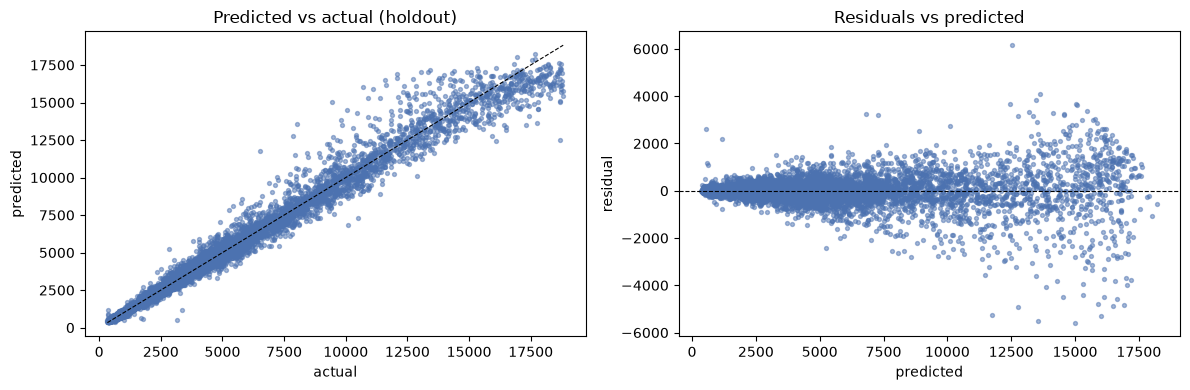

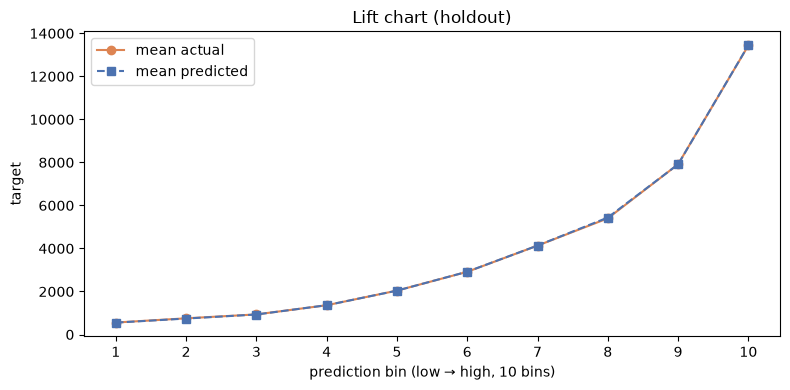

In [10]:
aml.evaluate()
aml.ci

## 10 · Explainability

Permutation importance, partial dependence, SHAP — with the correlated-features caveat stated honestly.

[explain] SHAP skipped: champion is not a plain pipeline (calibrated ensembles explain poorly)


,feature,importance,std
0,y,5602.531904,18.713958
1,clarity,1133.171359,25.443053
2,color,820.037946,6.977774
3,depth,111.607646,5.906659
4,cut,30.037532,1.063345
5,table,9.024988,2.005155


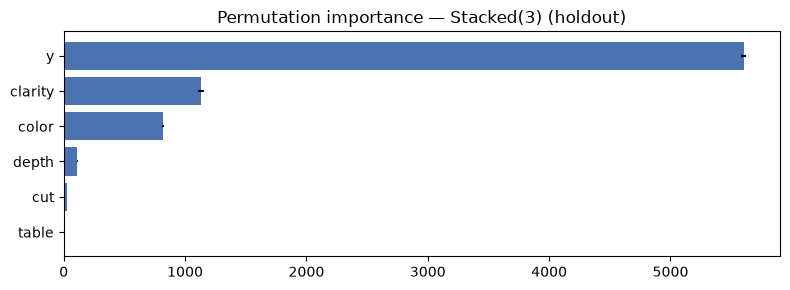

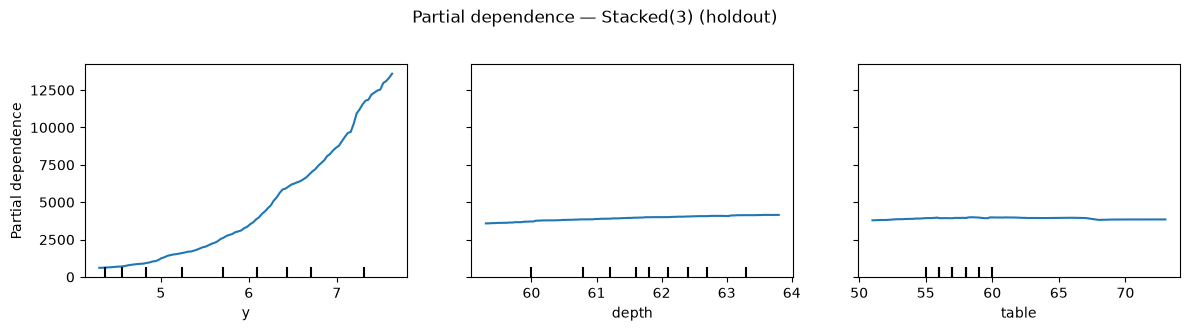

In [11]:
aml.explain().head(15)

## 11 · Using the exported artifact

Everything the artifact needs ships in the artifact folder — no code from this
repo is required at inference time.

**Batch scoring from the command line** (schema checks, recipe application,
probabilities and label decoding included):

```bash
python artifacts_regression/predict.py --input new_rows.csv --output predictions.csv
python artifacts_regression/predict.py --input new_rows.csv --output predictions.csv --drift-report
```

**In any Python process:**

```python
import joblib, pandas as pd

bundle = joblib.load("artifacts_regression/model.joblib")
pipe, le, meta = bundle["pipeline"], bundle["label_encoder"], bundle["metadata"]

new_data = pd.read_csv("new_rows.csv")            # raw rows, original column names
# stateless prep (renames / dates / text-NaN) is recorded in
# meta["preprocessing_recipe"]; predict.py applies it for you — if you score
# manually and used date or text columns, apply it the same way.
predictions = pipe.predict(new_data[meta["features"]])
```

For binary classification the tuned decision threshold lives *inside* the
pipeline (`FixedThresholdClassifier`), so `predict()` already applies the
chosen operating point; `predict_proba()` still returns raw probabilities.

**In Docker** — the folder contains a ready `Dockerfile` and a pinned
`requirements.txt`:

```bash
cd artifacts_regression && docker build -t automl-scorer .
docker run -v $(pwd)/data:/data automl-scorer \
    python predict.py --input /data/new.csv --output /data/preds.csv
```

**Drift monitoring** — `drift_check.py` compares any new batch against the
training distribution (PSI per feature) using only the metadata file.

**Model report** — open `artifacts_regression/report.html` for the shareable summary
(leaderboard, holdout metrics with confidence intervals, all evaluation and
explainability figures, and the full decision audit).

In [12]:
artifact_dir = aml.export()
sorted(p.name for p in artifact_dir.iterdir())

[export] Exported model refit on 100% of rows (53,794); holdout metrics in the metadata describe the pre-refit model, which never saw the holdout


[artifacts] predict.py smoke test passed (scored 20 raw rows through the full recipe + pipeline)
[artifacts] Exported: model.joblib (4.53 MB), metadata.json, predict.py, drift_check.py, Dockerfile, requirements.txt -> artifacts_regression/


[export] Model report -> artifacts_regression/report.html
[export] Total runtime: 29.3 min


['Dockerfile',
 'drift_check.py',
 'metadata.json',
 'model.joblib',
 'predict.py',
 'report.html',
 'requirements.txt']

## 12 · Decision audit

Everything the automation decided on your behalf, in order — also shipped in `metadata.json` and `report.html`.

In [13]:
aml.log.to_frame()

,stage,decision
0,ingest,Dropped 146 duplicate rows — duplicates stradd...
1,quality,Normalized 3 categorical column(s) to string d...
2,quality,"0 feature(s) dropped, 9 remain (0 text)"
3,partition,Regression holdout stratified on target decile...
4,partition,"Train 43,035 rows / holdout 10,759 rows (locke..."
5,metric,Target reasonably symmetric (skew=1.62) -> pri...
6,objective,Strictly positive skewed target -> log1p-targe...
7,leakage,No leakage flags raised
8,correlation,"Dropping 'x' (|ρ|=0.998 with 'y', weaker targe..."
9,correlation,"Dropping 'carat' (|ρ|=0.996 with 'y', weaker t..."
